# **Linear Regression Activity**

### **Objective**
 > Investigate the relationship between pregnancy length in weeks of mothers and the weight of the baby at birth in pounds, and use linear regression to predict the weight at which a baby will be born.

* Response variable $y$ - birth weight
* Predictor variable $x$ - length of pregnancy

**Dataset:** North Carolina births, 1000 cases

**Description:** In 2004, the state of North Carolina released to the public a large data set containing information on births recorded in this state. This data set has been of interest to medical researchers who are studying the relation between habits and practices of expectant mothers and the birth of their children. This is a random sample of 1,000 cases from this data set.

**Format:** A data frame with 1000 observations on the following 13 variables.

**fage:** Father's age in years.

**mage:** Mother's age in years.

**mature:** Maturity status of mother.

**weeks:** Length of pregnancy in weeks.

**premie:** Whether the birth was classified as premature (premie) or full-term.

**visits:** Number of hospital visits during pregnancy.

**gained:** Weight gained by mother during pregnancy in pounds.

**weight:** Weight of the baby at birth in pounds.

**lowbirthweight:** Whether baby was classified as low birthweight (low) or not (not low).

**gender:** Gender of the baby, female or male.

**habit:** Status of the mother as a nonsmoker or a smoker.

**marital:** Whether mother is married or not married at birth.

**whitemom:** Whether mom is white or not white.

In [50]:
import pandas as pd
import numpy as np
import plotly.express as px
import requests
from io import StringIO

url = "https://openintro.org/data/csv/ncbirths.csv"
headers = {'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/58.0.3029.110 Safari/537.3'}
response = requests.get(url, headers=headers)
response.raise_for_status() # Raise an exception for bad status codes
df = pd.read_csv(StringIO(response.text))

In [51]:
df.head()

,fage,mage,mature,weeks,premie,visits,marital,gained,weight,lowbirthweight,gender,habit,whitemom
0,NaN,13,younger mom,39.0,full term,10.0,not married,38.0,7.63,not low,male,nonsmoker,not white
1,NaN,14,younger mom,42.0,full term,15.0,not married,20.0,7.88,not low,male,nonsmoker,not white
2,19.0,15,younger mom,37.0,full term,11.0,not married,38.0,6.63,not low,female,nonsmoker,white
3,21.0,15,younger mom,41.0,full term,6.0,not married,34.0,8.00,not low,male,nonsmoker,white
4,NaN,15,younger mom,39.0,full term,9.0,not married,27.0,6.38,not low,female,nonsmoker,not white


**Checks the number of rows and data types for each variable**

In [52]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   fage            829 non-null    float64
 1   mage            1000 non-null   int64  
 2   mature          1000 non-null   object 
 3   weeks           998 non-null    float64
 4   premie          998 non-null    object 
 5   visits          991 non-null    float64
 6   marital         999 non-null    object 
 7   gained          973 non-null    float64
 8   weight          1000 non-null   float64
 9   lowbirthweight  1000 non-null   object 
 10  gender          1000 non-null   object 
 11  habit           999 non-null    object 
 12  whitemom        998 non-null    object 
dtypes: float64(5), int64(1), object(7)
memory usage: 101.7+ KB


**Check for any NAs within the dataset**

In [53]:
df.isna().sum()

fage              171
mage                0
mature              0
weeks               2
premie              2
visits              9
marital             1
gained             27
weight              0
lowbirthweight      0
gender              0
habit               1
whitemom            2
dtype: int64

**Remove all rows with NAs from the dataframe**

In [54]:
df = df.dropna().copy()

## **Data Analysis**

### **Objective**
Understand the data and identify patterns before building the model.

**Correlation matrix**

Correlation calculated using numpy (np.corrcoef)

In [56]:
np.corrcoef(df['weeks'],df['weight'])[0,1]

0.6358891119707288

R = 0.636, indicating a moderate positive correlation meaning that babies from longer pregnancies typically have a higher birth weight.

**Scatter plot**

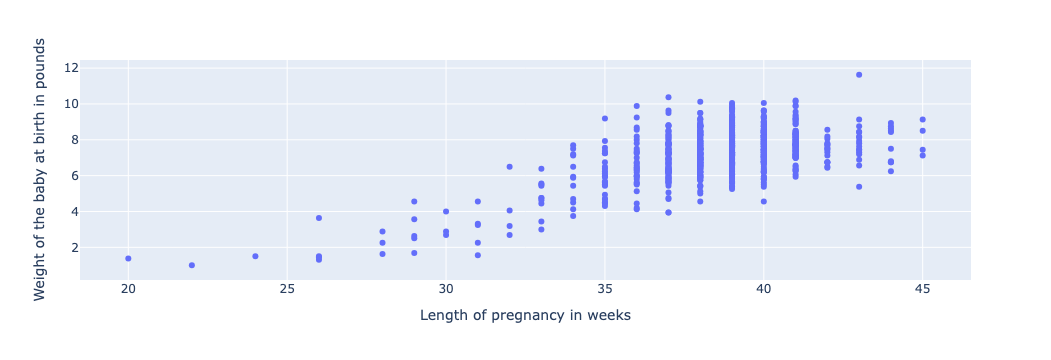

In [57]:
fig = px.scatter(
    df,
    x = "weeks",
    y = "weight",
    labels = {"weeks":"Length of pregnancy in weeks","weight":"Weight of the baby at birth in pounds"}
)
fig.show()

The scatter plot shows a moderate positive linear relationship between length of pregnancy and birth weight. As pregnancy length increases, the weight of the baby at birth also generally increases.

**Summary statistics**

In [58]:
df.describe()

,fage,mage,weeks,visits,gained,weight
count,800.000000,800.000000,800.000000,800.000000,800.000000,800.000000
mean,30.242500,27.611250,38.467500,12.441250,30.772500,7.208925
std,6.745968,6.164018,2.753802,3.772843,14.061931,1.440981
min,14.000000,15.000000,20.000000,0.000000,0.000000,1.000000
25%,25.000000,22.000000,38.000000,10.000000,21.750000,6.545000
50%,30.000000,28.000000,39.000000,12.000000,30.000000,7.380000
75%,35.000000,33.000000,40.000000,15.000000,39.000000,8.130000
max,55.000000,50.000000,45.000000,30.000000,85.000000,11.630000


**Box plots**

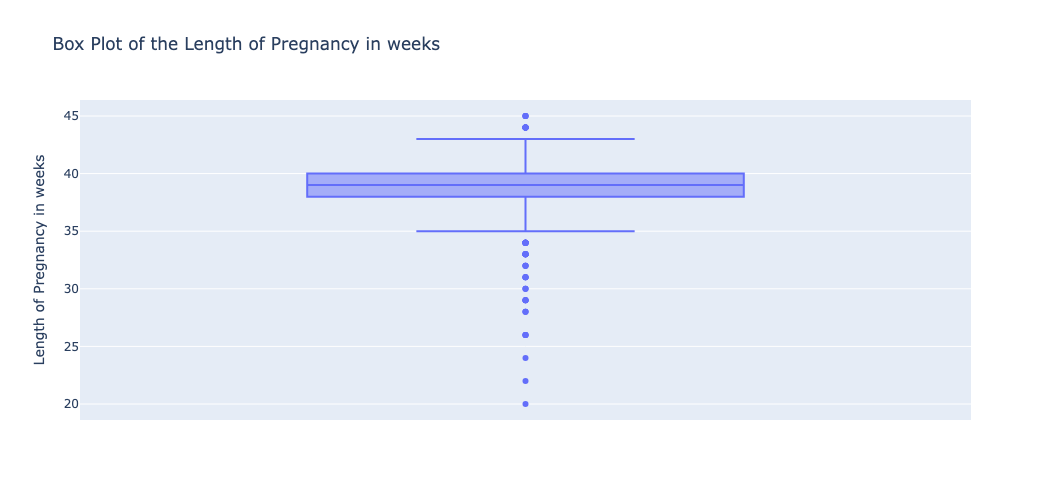

In [59]:
import plotly.express as px

fig = px.box(
    df,
    y="weeks",
    title="Box Plot of the Length of Pregnancy in weeks",
    labels={"weeks": "Length of Pregnancy in weeks"},
    width=600,
    height=500

)

fig.show()

The box plot indicates that pregnancy length is roughly symmetric. The median pregnancy length is 39 weeks, with the middle 50% of lengths ranging from about 38 weeks (Q1) to 40 weeks (Q3). There are two high-length outliers above the upper whisker of 43 weeks, and 11 low-length outliers below the lower fence of 35 weeks, indicating there are a few pregnancies that must last longer and shorter than the rest.

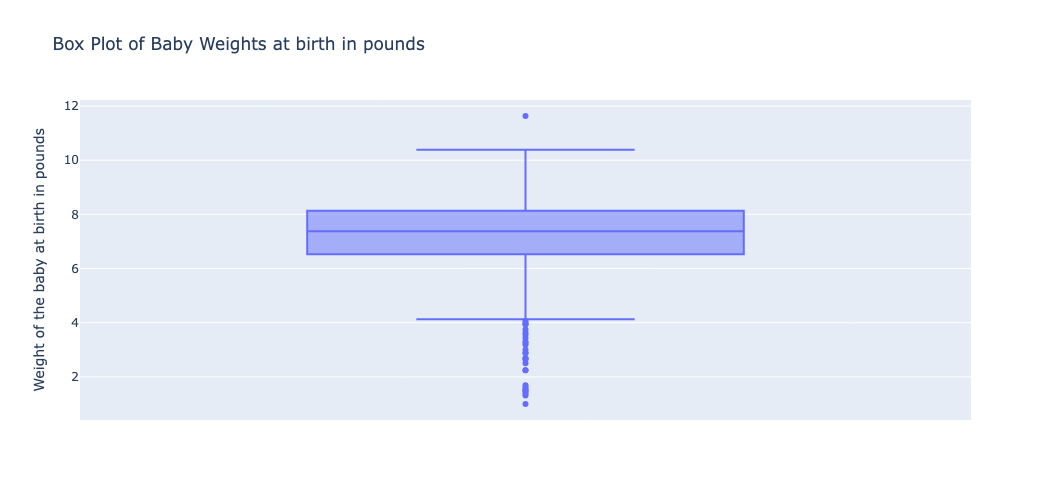

In [60]:
fig = px.box(
    df,
    y="weight",
    title="Box Plot of Baby Weights at birth in pounds",
    labels={"weight": "Weight of the baby at birth in pounds"},
    width=600,
    height=500
)

fig.show()

The box plot shows that birth weights are approximately symmetric. The median birth weight is about 7.4 pounds, and the middle 50% of values range from 6.53 (Q1) to 8.13 (Q3). There is one high end outlier, suggesting there was one baby that weighed significantly more than the rest. There are 20 low end outliers, where babies weigh much less than the rest of the data set.

## **Split the Data into Training and Test Sets**

Splits:
- 80% Training
- 20% Testing

In [61]:
from sklearn.model_selection import train_test_split

df_train, df_test = train_test_split(
    df,
    test_size=0.20,      # 20% test, 80% training
    random_state=19      # Reproducible split
)

In [62]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 640 entries, 569 to 787
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   fage            640 non-null    float64
 1   mage            640 non-null    int64  
 2   mature          640 non-null    object 
 3   weeks           640 non-null    float64
 4   premie          640 non-null    object 
 5   visits          640 non-null    float64
 6   marital         640 non-null    object 
 7   gained          640 non-null    float64
 8   weight          640 non-null    float64
 9   lowbirthweight  640 non-null    object 
 10  gender          640 non-null    object 
 11  habit           640 non-null    object 
 12  whitemom        640 non-null    object 
dtypes: float64(5), int64(1), object(7)
memory usage: 70.0+ KB


In [63]:
df_test.info()

<class 'pandas.core.frame.DataFrame'>
Index: 160 entries, 980 to 232
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   fage            160 non-null    float64
 1   mage            160 non-null    int64  
 2   mature          160 non-null    object 
 3   weeks           160 non-null    float64
 4   premie          160 non-null    object 
 5   visits          160 non-null    float64
 6   marital         160 non-null    object 
 7   gained          160 non-null    float64
 8   weight          160 non-null    float64
 9   lowbirthweight  160 non-null    object 
 10  gender          160 non-null    object 
 11  habit           160 non-null    object 
 12  whitemom        160 non-null    object 
dtypes: float64(5), int64(1), object(7)
memory usage: 17.5+ KB


## **Diagnose Regression Assumptions**

In [64]:
import statsmodels.formula.api as smf
model = smf.ols('weight ~ weeks',data=df_train).fit()
df_train["residuals"] = model.resid
df_train["fitted"] = model.fittedvalues

In [65]:
df_train.head()

,fage,mage,mature,weeks,premie,visits,marital,gained,weight,lowbirthweight,gender,habit,whitemom,residuals,fitted
569,29.0,28,younger mom,37.0,full term,5.0,not married,35.0,6.44,not low,male,nonsmoker,not white,-0.316502,6.756502
909,40.0,36,mature mom,38.0,full term,26.0,married,20.0,7.19,not low,female,nonsmoker,white,0.102937,7.087063
39,28.0,18,younger mom,41.0,full term,10.0,not married,11.0,6.50,not low,female,nonsmoker,not white,-1.578747,8.078747
138,21.0,20,younger mom,38.0,full term,8.0,married,35.0,6.75,not low,male,nonsmoker,not white,-0.337063,7.087063
27,20.0,17,younger mom,40.0,full term,10.0,not married,68.0,7.44,not low,male,nonsmoker,not white,-0.308186,7.748186


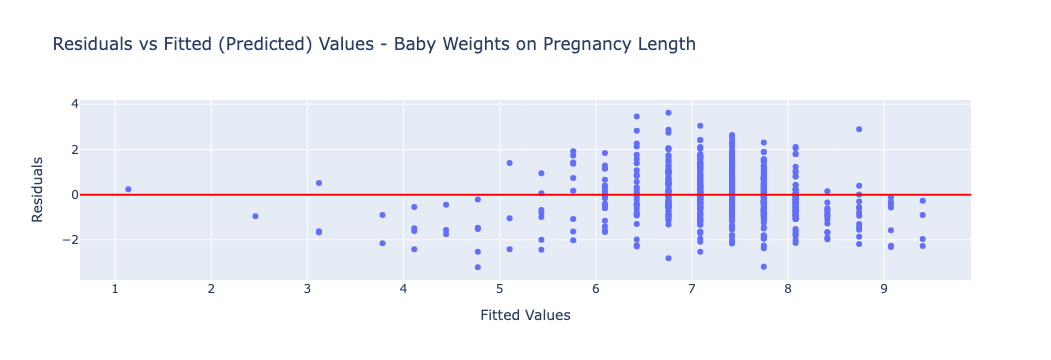

In [66]:
# Plot Residuals vs Fitted
fig = px.scatter(df_train, x='fitted', y='residuals',
                 title='Residuals vs Fitted (Predicted) Values - Baby Weights on Pregnancy Length',
                 labels={'fitted': 'Fitted Values', 'residuals': 'Residuals'},
                 hover_data=['weeks', 'weight'])
fig.add_hline(y=0, line_color='red')
fig.show()

### **A) Linearity**

In this residuals vs predicted values plot, the residuals are scattered evenly above and below the zero line with no curved or clear pattern, supporting the linearity assumption being satisfied. The vertical grouping in this plot is expected because pregnancy length is recorded in whole weeks, so there are only a limited number of possible fitted values.

### **B) Independence**
The North Carolina birth dataset is cross-sectional, with each observation representing a different pregnancy. Therefore, the observations are assumed to be independent, and the independence assumption is considered satisfied.

### **C) Homoscedasticity**

Looking at the Residuals vs Fitted plot above, the spread of the residuals stays reasonably constant across all of the fitted values, so the homoscedasticity assumption is reasonably satisfied.

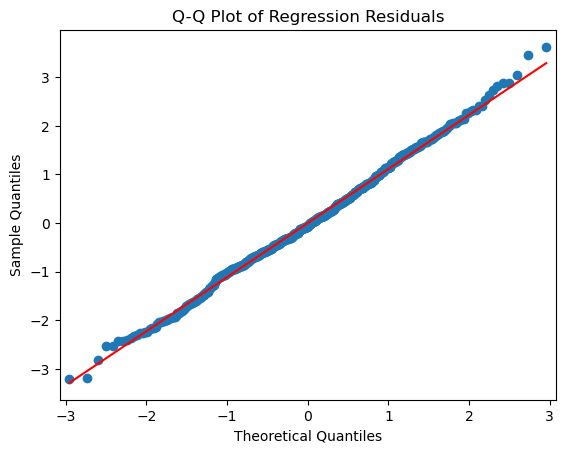

In [67]:
import statsmodels.api as sm
import matplotlib.pyplot as plt
sm.qqplot(df_train["residuals"], line='s')
plt.title("Q-Q Plot of Regression Residuals")
plt.show()

### **D) Normality of Residuals**

The Q-Q plot above compares the residuals against the values expected under a normal distribution. Most of the residual points fall very close to the reference line through the middle of the distribution, which supports normality.

In [68]:
import statsmodels.formula.api as smf
from statsmodels.stats.outliers_influence import OLSInfluence

# Fit the model
model = smf.ols('weight ~ weeks',data=df_train).fit()

# Get influence measures
influence = OLSInfluence(model)

# Studentized residuals (externally studentized)
studentized_residuals = influence.resid_studentized_external

# Add to DataFrame
df_train['Studentized_Residual'] = studentized_residuals

# Flag outliers
df_train['Outlier'] = df_train['Studentized_Residual'].abs() > 3

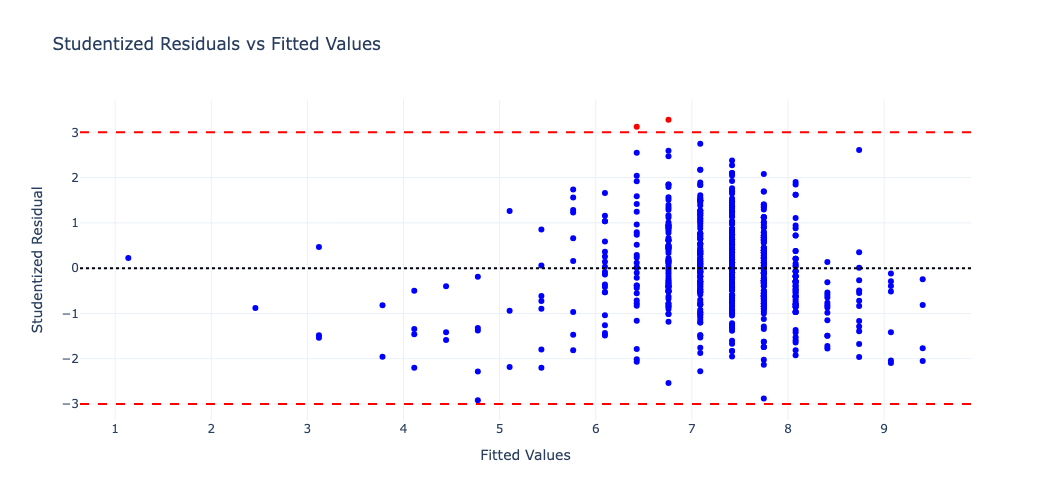

In [69]:
fig = px.scatter(
    df_train,
    x='fitted',
    y='Studentized_Residual',
    color='Outlier',
    color_discrete_map={True: 'red', False: 'blue'},
    hover_data=['weeks', 'weight'],
    title='Studentized Residuals vs Fitted Values',
    labels={
        'fitted': 'Fitted Values',
        'Studentized_Residual': 'Studentized Residual'
    }
)

# Reference lines
fig.add_hline(y=3, line_dash='dash', line_color='red')
fig.add_hline(y=-3, line_dash='dash', line_color='red')
fig.add_hline(y=0, line_dash='dot', line_color='black')

fig.update_layout(
    template='plotly_white',
    showlegend=False,
    width=800,
    height=500
)

fig.show()

### **E) Influential Observations**

* **Studentized residuals** put each residual into standard deviation units, which makes it easier to see which observations the model predicts poorly. Studentized residuals past +3 or -3 are looked at as potential outliers. In the plot there are two observations above the +3 line in red, meaning their actual birth weight was much higher than the model predicted for their pregnancy length, so these are potential outliers.

In [70]:
# Calculate Cook's Distance
cooks_d = influence.cooks_distance[0]

# Add Cook's Distance to the DataFrame
df_train['Cooks_Distance'] = cooks_d

# Set the threshold
threshold = 4 / len(df_train)

# Flag potentially influential observations
df_train['Influential'] = df_train['Cooks_Distance'] > threshold

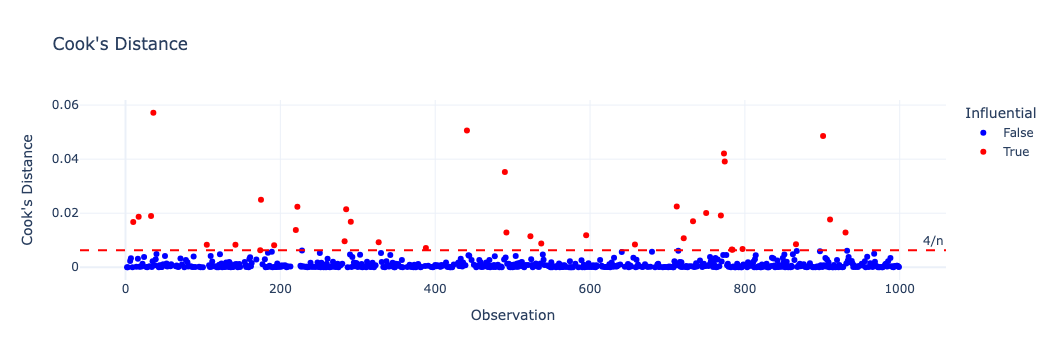

In [71]:
fig = px.scatter(
    df_train,
    x=df_train.index,
    y='Cooks_Distance',
    color='Influential',
    color_discrete_map={True: 'red', False: 'blue'},
    title="Cook's Distance",
    labels={
        'x': 'Observation',
        'Cooks_Distance': "Cook's Distance"
    }
)

fig.add_hline(
    y=4/len(df_train),
    line_dash='dash',
    line_color='red',
    annotation_text='4/n'
)

fig.update_layout(
    template='plotly_white',
    xaxis_title='Observation'
)
fig.show()

* **Cook's Distance** looks at observations with unusual predictor values and large residuals. It measures how much the fitted model would change if that one observation were removed. The points plotted above the 4/n line in red are flagged as potentially influential.

In [72]:
threshold = 4 / len(df_train)

df_train[df_train['Cooks_Distance'] > threshold][
    ['weeks', 'weight', 'Cooks_Distance']
]

,weeks,weight,Cooks_Distance
490,31.0,2.25,0.035245
142,43.0,6.88,0.008320
523,43.0,6.56,0.011429
712,45.0,7.13,0.022456
774,26.0,1.50,0.039128
105,32.0,6.50,0.008362
285,30.0,2.69,0.021441
175,32.0,2.69,0.024987
174,34.0,4.13,0.006310
658,40.0,4.56,0.008447


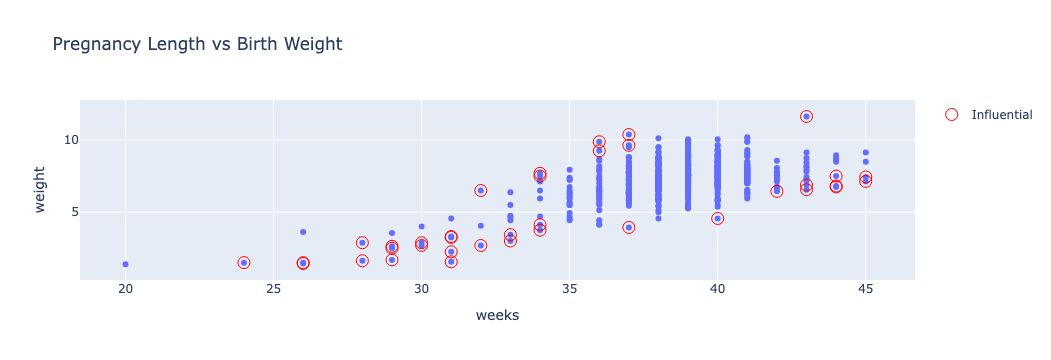

In [73]:
fig = px.scatter(
    df_train,
    x='weeks',
    y='weight',
    title='Pregnancy Length vs Birth Weight'
)

# Highlight influential observations
influential = df_train[df_train['Cooks_Distance'] > threshold]

fig.add_scatter(
    x=influential['weeks'],
    y=influential['weight'],
    mode='markers',
    marker=dict(color='red', size=12, symbol='circle-open'),
    name='Influential'
)

fig.show()

37 observations exceed the 4/n threshold and are therefore considered potentially influential. These observations may have a noticeable effect on the fitted regression model and should be examined further. The largest Cook's Distance in this model is only about 0.057 so while these 37 points are marked, none of them are powerful enough on their own to be considered strongly influential.

## **Examine the Statistical Summary**

**Objective**

Examine and interpret the statistical summary of the regression model fitted on the training dataset to evaluate its performance and understand the relationship between the predictor variables and the response variable.

In [74]:
import statsmodels.formula.api as smf
model = smf.ols('weight ~ weeks',data=df_train).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                 weight   R-squared:                       0.394
Model:                            OLS   Adj. R-squared:                  0.393
Method:                 Least Squares   F-statistic:                     414.7
Date:                Fri, 24 Jul 2026   Prob (F-statistic):           2.10e-71
Time:                        22:18:35   Log-Likelihood:                -976.73
No. Observations:                 640   AIC:                             1957.
Df Residuals:                     638   BIC:                             1966.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -5.4743      0.626     -8.744      0.0

### **A) Regression Coefficients**

Regression Equation with Coefficients: $\widehat{\text{weight}} = 0.3306(\text{weeks}) - 5.4743$

* Intercept (-5.4743): The intercept represents the predicted weight when pregnancy length is zero. A pregnancy length of 0 does not make any sense in this context so the value isn't very practical.

* Weeks (0.3306): The coefficient for weeks is a positive value, showing a positive relationship between pregnancy length and birth weight. This value means that each single week increase in pregnancy length will have an average increase of 0.3306 pounds in the predicted birth weight.

### **B) Confidence Interval**

* From the regression model summary, the 95% confidence interval for the pregnancy length in week would be [0.299, 0.362]. This means that there is 95% confidence that for every 1 week increase in pregnancy length the expected birth weight increases by between 0.299 and 0.362 pounds. Since it does not include zero, there is significant evidence that pregnancy length is a predictor of birth weight.

### **C) Standard Error**
* The estimated intercept from the model summary is -5.4743, and its standard error is 0.626, demonstrating a decently precise estimate. That means that collecting many similar samples and fitting them to the same regression model, the estimated intercept would typically vary by about 0.626 units.

### **D) t-Statistics and p-Values**

* t = 20.364 and p-value = 0.000, meaning that if pregnancy length had no real relationship with birth weight, there would be essentially no chance of seeing a t-statistic as extreme as 20.364. Since the p-value is well below 0.05 the null hypothesis is rejected, meaning pregnancy length is a statistically significant predictor of birth weight.

### **E) Training $R^2$ and Adjusted $R^2$**

* Training $R^2$ is 0.394 meaning that around 39.4% of the variation in baby birth weight can be explained by pregnancy length, while the other 60.6% is from other factors.

* This $R^2$ value of 0.394 is fairly low, suggesting the model only provides a moderate fit to the training data. Even though the p-value of 0.000 shows that pregnancy length is a statistically significant predictor of birth weight, it still leaves most of the variation unexplained, likely due to other predictors not included in the model.

In [75]:
RSE = np.sqrt(model.mse_resid)
print(RSE)

1.1149102371611503


### **F) Residual Standard Error**

* The Residual Standard Error of 1.115 explains that the model’s prediction error is approximately 1.115 pounds on average.

### **G) F-Statistics**

The F-statistic is 414.7, indicating that the regression model provides a much better fit than a model with no predictor variables. The very small corresponding p-value of (2.10e-71) is also less than 0.05, showing that the regression model is statistically significant. Therefore, pregnancy length is a significant predictor of birth weight.

## **Evaluate the Model on the Test Data**

In [76]:
from sklearn.metrics import (
    root_mean_squared_error,
    mean_absolute_error,
    r2_score
)
import pandas as pd

y_test = df_test['weight']
y_pred = model.predict(df_test)

results = pd.DataFrame({
    "Metric": ["RMSE", "MAE", "Test R²"],
    "Value": [
        root_mean_squared_error(y_test, y_pred),
        mean_absolute_error(y_test, y_pred),
        r2_score(y_test, y_pred)
    ]
})

print(results)

    Metric     Value
0     RMSE  1.106928
1      MAE  0.871971
2  Test R²  0.434707


Root Mean Squared Error: The RMSE is approximately 1.11, meaning that the model’s predictions vary from the actual birth weight amounts by on average 1.11 pounds.

Mean Absolute Error: The MAE is 0.87, meaning that the average absolute prediction error is 0.87.

Test $R^2$: The Test $R^2$ is 0.435, which says that the model explains 43.5% of the variation in birth weights for unseen observations.

Training $R^2$ is 0.394, Test $R^2$ is 0.435

The higher test $R^2$ value suggests that the model performed slightly better on the test data. Both values are well below the maximum possible value of 1, meaning that while pregnancy length does explain some of the variability in birth weights, it is not a very large proportion.

## **Conclusion**

Pregnancy length is a statistically significant predictor of birth weight. Each week of pregnancy has an average increase of about 0.33 pounds, and the model as a whole is significant based on both the t-test and F-test.

However, the model explains only 39.4% of the variation in birth weight on the training data and 43.5% on the test data, with a typical prediction error of just over one pound. By itself, pregnancy length is not enough to completely predict birth weight accurately, and other predictors would need to be added improve the model.